# 2 Scaling Laws Review
## 2.1 Scaling Laws from IsoFLOPs profiles
### Problem (chinchilla_isoflops): IsoFLOPs scaling laws ###
Write a script to reproduce the IsoFLOPs method described above for fitting scaling laws using
the final training loss from a set of training runs. For this problem, use the (synthetic) data from
training runs given in the file data/isoflops_curves.json. This file contains a JSON array, where
each element is an object describing a training run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_json("data/isoflops_curves.json")
df.head()

,parameters,compute_budget,final_loss
0,49999999,6.000000e+18,7.192785
1,78730505,6.000000e+18,6.750171
2,123969849,6.000000e+18,6.406640
3,195204177,6.000000e+18,6.154369
4,307370470,6.000000e+18,5.987783


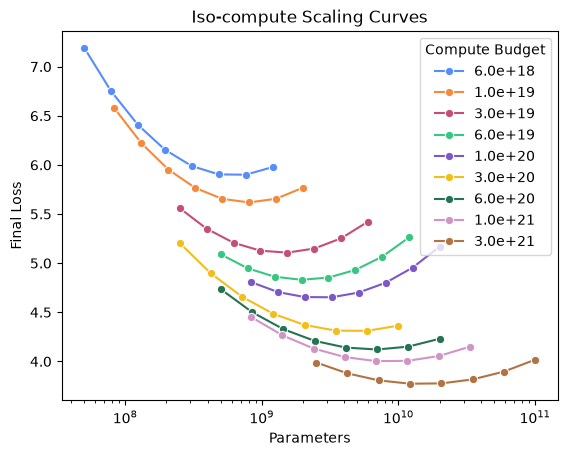

In [3]:
df["compute_label"] = df["compute_budget"].map(lambda x: f"{x:.1e}")

sns.lineplot(
    data=df,
    x="parameters",
    y="final_loss",
    hue="compute_label",
    marker="o"
)

plt.xscale("log")
plt.xlabel("Parameters")
plt.ylabel("Final Loss")
plt.title("Iso-compute Scaling Curves")
plt.legend(title="Compute Budget")
plt.show()

In [4]:
best_runs = df.loc[df.groupby("compute_budget")["final_loss"].idxmin()]
best_runs["dataset_size"] = best_runs["compute_budget"] / (best_runs["parameters"] * 6)
best_runs[["log_parameters", "log_dataset_size", "log_compute_budget"]] = (
    np.log(best_runs[["parameters", "dataset_size", "compute_budget"]]))
best_runs

,parameters,compute_budget,final_loss,compute_label,dataset_size,log_parameters,log_dataset_size,log_compute_budget
6,762093419,6.000000e+18,5.899930,6.0e+18,1.312175e+09,20.451580,20.994952,43.238291
13,806647749,1.000000e+19,5.617943,1.0e+19,2.066164e+09,20.508398,21.448960,43.749117
20,1536852354,3.000000e+19,5.107177,3.0e+19,3.253403e+09,21.153002,21.902967,44.847729
27,1952041776,6.000000e+19,4.830586,6.0e+19,5.122841e+09,21.392142,22.356975,45.540876
35,3253402960,1.000000e+20,4.652893,1.0e+20,5.122841e+09,21.902967,22.356975,46.051702
46,5903836027,3.000000e+20,4.311219,3.0e+20,8.469070e+09,22.498868,22.859687,47.150314
53,6971055968,6.000000e+20,4.121241,6.0e+20,1.434503e+10,22.665033,23.386669,47.843461
60,6859328563,1.000000e+21,4.002835,1.0e+21,2.429781e+10,22.648875,23.913652,48.354287
67,12148905329,3.000000e+21,3.773188,3.0e+21,4.115597e+10,23.220505,24.440635,49.452899


(a) Compute-Optimal Model Size Scaling Law

Show your extrapolated compute-optimal model size, together with the
$\langle C_i, N_{\mathrm{opt}}(C_i) \rangle$ points you obtained.

What is your predicted optimal model size for a budget of
$10^{23}$ FLOPs? What about for $10^{24}$ FLOPs?

**Deliverable**

- A plot showing your scaling law for **model size vs. compute budget**.
- Include the data points used to fit the scaling law:
  $$
  \left\{\left(C_i, N_{\mathrm{opt}}(C_i)\right)\right\}.
  $$
- Extrapolate the fitted scaling law up to at least
  $10^{24}$ FLOPs.
- Then, provide a **one-sentence** response with your predicted optimal model size for:
  - $10^{23}$ FLOPs
  - $10^{24}$ FLOPs

In [5]:
reg1 = LinearRegression()
reg1.fit(best_runs[["log_compute_budget"]], best_runs["log_parameters"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['log_compute_budget']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1514
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


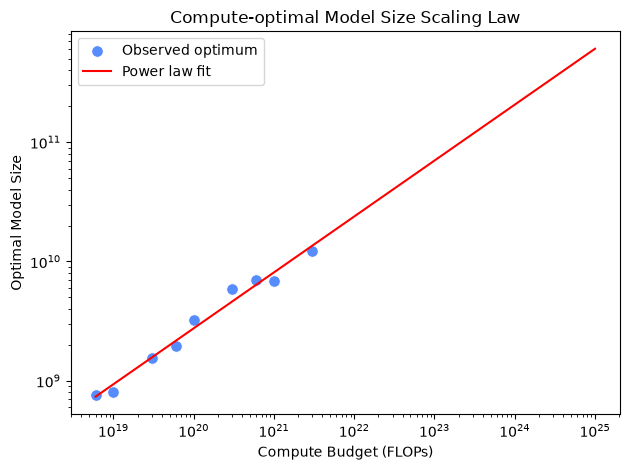

In [6]:
compute_pred = np.logspace(
    np.log10(best_runs["compute_budget"].min()),
    25,
    1000
)

log_parameters_pred = reg1.predict(np.log(compute_pred).reshape(-1, 1))
parameters_pred = np.exp(log_parameters_pred)
pred_df = pd.DataFrame({
    "compute_budget": compute_pred,
    "parameters": parameters_pred
})


ax = sns.scatterplot(
    data=best_runs,
    x="compute_budget",
    y="parameters",
    s=70,
    label="Observed optimum"
)

sns.lineplot(
    data=pred_df,
    x="compute_budget",
    y="parameters",
    color="red",
    ax=ax,
    label="Power law fit"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Compute Budget (FLOPs)")
ax.set_ylabel("Optimal Model Size")
ax.set_title("Compute-optimal Model Size Scaling Law")

plt.tight_layout()
plt.show()

In [7]:
compute_targets = np.array([1e23, 1e24])

log_compute = np.log(compute_targets).reshape(-1, 1)
log_parameters = reg1.predict(log_compute)
parameters = np.exp(log_parameters)

print(
    f"Predicted optimal model size: "
    f"{parameters[0]:.3e} parameters for 1e23 FLOPs, "
    f"and {parameters[1]:.3e} parameters for 1e24 FLOPs."
)

Predicted optimal model size: 7.005e+10 parameters for 1e23 FLOPs, and 2.061e+11 parameters for 1e24 FLOPs.


(b) Compute-Optimal Dataset Size Scaling Law

Show your extrapolated compute-optimal dataset size, together with the
$\langle C_i, D_{\mathrm{opt}}(C_i) \rangle$ data points from the training runs.

What is your predicted optimal dataset size for budgets of
$10^{23}$ FLOPs and $10^{24}$ FLOPs?

**Deliverable**

- A plot showing your scaling law for **dataset size vs. compute budget**.
- Include the data points used to fit the scaling law:
  $$
  \left\{\left(C_i, D_{\mathrm{opt}}(C_i)\right)\right\}.
  $$
- Extrapolate the fitted scaling law up to at least
  $10^{24}$ FLOPs.
- Then, provide a **one-sentence** response with your predicted optimal dataset size for:
  - $10^{23}$ FLOPs
  - $10^{24}$ FLOPs

In [8]:
reg2 = LinearRegression()
reg2.fit(best_runs[["log_compute_budget"]], best_runs["log_dataset_size"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.53]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['log_compute_budget']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.943
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


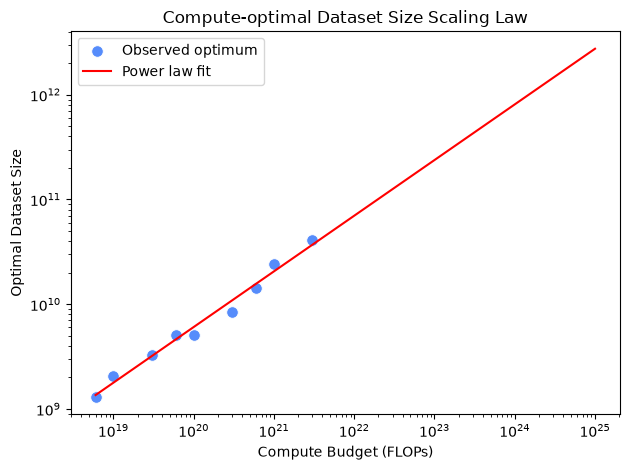

In [9]:
log_dataset_pred = reg2.predict(
    np.log(compute_pred).reshape(-1, 1)
)

dataset_pred = np.exp(log_dataset_pred)

pred_df = pd.DataFrame({
    "compute_budget": compute_pred,
    "dataset_size": dataset_pred
})

ax = sns.scatterplot(
    data=best_runs,
    x="compute_budget",
    y="dataset_size",
    s=70,
    label="Observed optimum"
)

sns.lineplot(
    data=pred_df,
    x="compute_budget",
    y="dataset_size",
    color="red",
    ax=ax,
    label="Power law fit"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Compute Budget (FLOPs)")
ax.set_ylabel("Optimal Dataset Size")
ax.set_title("Compute-optimal Dataset Size Scaling Law")

plt.tight_layout()
plt.show()

In [10]:
compute_targets = np.array([1e23, 1e24])

log_compute = np.log(compute_targets).reshape(-1, 1)
log_dataset = reg2.predict(log_compute)
dataset_size = np.exp(log_dataset)

print(
    f"Predicted optimal dataset size: "
    f"{dataset_size[0]:.3e} tokens for 1e23 FLOPs, "
    f"and {dataset_size[1]:.3e} tokens for 1e24 FLOPs."
)

Predicted optimal dataset size: 2.379e+11 tokens for 1e23 FLOPs, and 8.086e+11 tokens for 1e24 FLOPs.
